# Tarea - Redes Neuronales
Fernando Sebastián Baque

## Parte 1: Perceptrón de Rosenblatt para AND

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0, 0, 0, 1])

w = np.zeros(2)
b = 0.0
lr = 0.2

def escalon(z):
    return 1 if z >= 0 else 0

print(f"Inicial: w = {w}, b = {b}\n")

# regla de Rosenblatt: w <- w + lr*(y - pred)*x
for epoca in range(1, 21):
    errores = 0
    for xi, yi in zip(X, y):
        pred = escalon(np.dot(w, xi) + b)
        err = yi - pred
        w += lr * err * xi
        b += lr * err
        errores += int(err != 0)
    print(f"Época {epoca}: w = {w}, b = {b:.2f}, errores = {errores}")
    if errores == 0:
        print(f"\nConvergió en la época {epoca}")
        break

Inicial: w = [0. 0.], b = 0.0

Época 1: w = [0.2 0.2], b = 0.00, errores = 2
Época 2: w = [0.4 0.2], b = -0.20, errores = 3
Época 3: w = [0.4 0.2], b = -0.40, errores = 3
Época 4: w = [0.4 0.2], b = -0.40, errores = 0

Convergió en la época 4


Frontera: (0.40)·x1 + (0.20)·x2 + (-0.40) = 0
Despejando: x2 = (-2.00)·x1 + (2.00)

[0 0] -> 0 (esperado 0)
[0 1] -> 0 (esperado 0)
[1 0] -> 0 (esperado 0)
[1 1] -> 1 (esperado 1)


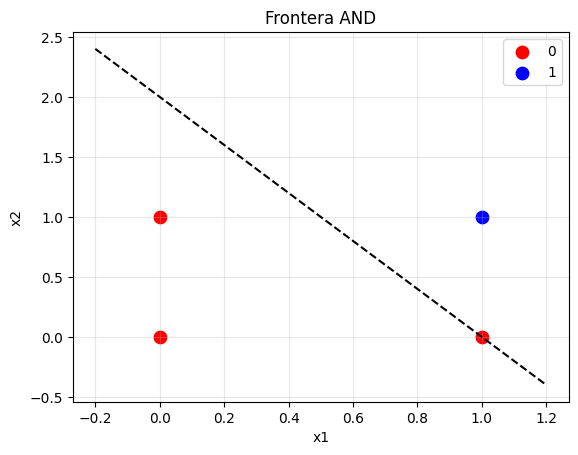

In [4]:
# frontera: w1*x1 + w2*x2 + b = 0
print(f"Frontera: ({w[0]:.2f})·x1 + ({w[1]:.2f})·x2 + ({b:.2f}) = 0")
print(f"Despejando: x2 = ({-w[0]/w[1]:.2f})·x1 + ({-b/w[1]:.2f})\n")

for xi, yi in zip(X, y):
    print(f"{xi} -> {escalon(np.dot(w, xi) + b)} (esperado {yi})")

xs = np.linspace(-0.2, 1.2, 50)
ys = -(w[0]*xs + b) / w[1]
plt.scatter(X[y==0,0], X[y==0,1], c='red', s=80, label='0')
plt.scatter(X[y==1,0], X[y==1,1], c='blue', s=80, label='1')
plt.plot(xs, ys, 'k--')
plt.xlabel('x1'); plt.ylabel('x2'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Frontera AND')
plt.show()

## Parte 2: MLP para Iris

El flujo: normalizo con z-score, paso las etiquetas a one-hot, split 80/20, red con ReLU en las ocultas y softmax en la salida, entreno con cross-entropy. Al correr la celda de abajo se abre el diálogo para subir el `iris.csv`.

In [5]:
import numpy as np
import pandas as pd
from google.colab import files
import io

up = files.upload()
df = pd.read_csv(io.BytesIO(up[next(iter(up))]))

# la versión de Kaggle trae columna Id, la tiramos si está
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

X = df.iloc[:, :4].values.astype(float)
y_raw = df.iloc[:, 4].values
clases = np.unique(y_raw)
y = np.array([np.where(clases == c)[0][0] for c in y_raw])

# z-score
X = (X - X.mean(axis=0)) / X.std(axis=0)

# one-hot
Y = np.zeros((len(y), 3))
Y[np.arange(len(y)), y] = 1

# split 80/20
np.random.seed(7)
idx = np.random.permutation(len(X))
n = int(0.8 * len(X))
X_tr, X_te = X[idx[:n]], X[idx[n:]]
Y_tr, Y_te = Y[idx[:n]], Y[idx[n:]]
y_te = y[idx[n:]]

print("Clases:", dict(enumerate(clases)))
print("Train:", X_tr.shape, "| Test:", X_te.shape)

Saving Iris.csv to Iris.csv
Clases: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
Train: (120, 4) | Test: (30, 4)


In [6]:
class RedNeuronal:
    def __init__(self, capas):
        self.W, self.b = [], []
        for i in range(len(capas)-1):
            # init He, va bien con ReLU
            self.W.append(np.random.randn(capas[i], capas[i+1]) * np.sqrt(2/capas[i]))
            self.b.append(np.zeros(capas[i+1]))

    def _softmax(self, z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def forward(self, X):
        self.a = [X]
        self.z = []
        h = X
        for i in range(len(self.W)-1):
            zi = h @ self.W[i] + self.b[i]
            h = np.maximum(0, zi)  # relu
            self.z.append(zi)
            self.a.append(h)
        zi = h @ self.W[-1] + self.b[-1]
        out = self._softmax(zi)
        self.z.append(zi)
        self.a.append(out)
        return out

    def backward(self, Y, lr):
        m = Y.shape[0]
        dZ = self.a[-1] - Y  # softmax + CE simplifica el gradiente a esto
        for i in reversed(range(len(self.W))):
            dW = self.a[i].T @ dZ / m
            db = dZ.mean(axis=0)
            if i > 0:
                dZ = (dZ @ self.W[i].T) * (self.z[i-1] > 0)
            self.W[i] -= lr * dW
            self.b[i] -= lr * db

    def entrenar(self, X, Y, epocas=2000, lr=0.05):
        for ep in range(1, epocas+1):
            out = self.forward(X)
            loss = -np.mean(np.sum(Y * np.log(out + 1e-9), axis=1))
            self.backward(Y, lr)
            if ep % 200 == 0:
                acc = (np.argmax(out, 1) == np.argmax(Y, 1)).mean()
                print(f"Época {ep}: loss = {loss:.4f}, acc_train = {acc:.4f}")

    def predecir(self, X):
        return np.argmax(self.forward(X), axis=1)

In [7]:
red = RedNeuronal([4, 10, 8, 3])
red.entrenar(X_tr, Y_tr, epocas=2000, lr=0.05)

pred = red.predecir(X_te)
acc = (pred == y_te).mean()
print(f"\nAccuracy en test: {acc:.4f}\n")

for i in range(min(10, len(y_te))):
    print(f"Real: {clases[y_te[i]]:15s} | Predicho: {clases[pred[i]]}")

Época 200: loss = 0.1737, acc_train = 0.9417
Época 400: loss = 0.0784, acc_train = 0.9667
Época 600: loss = 0.0527, acc_train = 0.9833
Época 800: loss = 0.0421, acc_train = 0.9917
Época 1000: loss = 0.0366, acc_train = 0.9917
Época 1200: loss = 0.0333, acc_train = 0.9917
Época 1400: loss = 0.0310, acc_train = 0.9917
Época 1600: loss = 0.0293, acc_train = 0.9917
Época 1800: loss = 0.0281, acc_train = 0.9917
Época 2000: loss = 0.0271, acc_train = 0.9917

Accuracy en test: 0.9667

Real: Iris-setosa     | Predicho: Iris-setosa
Real: Iris-versicolor | Predicho: Iris-versicolor
Real: Iris-versicolor | Predicho: Iris-versicolor
Real: Iris-virginica  | Predicho: Iris-virginica
Real: Iris-virginica  | Predicho: Iris-virginica
Real: Iris-versicolor | Predicho: Iris-versicolor
Real: Iris-virginica  | Predicho: Iris-versicolor
Real: Iris-setosa     | Predicho: Iris-setosa
Real: Iris-versicolor | Predicho: Iris-versicolor
Real: Iris-versicolor | Predicho: Iris-versicolor
